In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [28]:
df = pd.read_csv("C:/Users/yashj/OneDrive/Desktop/ml_new/Datasets/quikr_car_extended.csv")

In [29]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Mini Cooper S,Mini,2002,"2,70,000","72,197 kms",Petrol
1,Jaguar XE Prestige,Jaguar,2020,"15,25,000","1,10,704 kms",Petrol
2,Jeep Compass Longitude,Jeep,2019,"1,69,000","52,224 kms",Diesel
3,Maruti Suzuki Swift Dzire Vdi,Maruti,2015,"56,000","89,294 kms",Diesel
4,Chevrolet Beat LT,Chevrolet,2004,"25,000","99,695 kms",Petrol


In [34]:
df.shape

(10500, 6)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        10500 non-null  object
 1   company     10500 non-null  object
 2   year        10500 non-null  int64 
 3   Price       10500 non-null  object
 4   kms_driven  10500 non-null  object
 5   fuel_type   10500 non-null  object
dtypes: int64(1), object(5)
memory usage: 492.3+ KB


In [36]:
backup = df.copy()

In [37]:
backup.head()

,name,company,year,Price,kms_driven,fuel_type
0,Mini Cooper S,Mini,2002,"2,70,000","72,197 kms",Petrol
1,Jaguar XE Prestige,Jaguar,2020,"15,25,000","1,10,704 kms",Petrol
2,Jeep Compass Longitude,Jeep,2019,"1,69,000","52,224 kms",Diesel
3,Maruti Suzuki Swift Dzire Vdi,Maruti,2015,"56,000","89,294 kms",Diesel
4,Chevrolet Beat LT,Chevrolet,2004,"25,000","99,695 kms",Petrol


In [39]:
df=df[df['Price']!='Ask For Price']

In [40]:

df['Price']=df['Price'].str.replace(',','').astype(int)

In [41]:
df['kms_driven']=df['kms_driven'].str.split().str.get(0).str.replace(',','')

In [42]:
df=df[df['kms_driven'].str.isnumeric()]

In [43]:
df['kms_driven']=df['kms_driven'].astype(int)

In [44]:
df=df[~df['fuel_type'].isna()]

In [46]:
df.shape

(10153, 6)

In [47]:
df['name']=df['name'].str.split().str.slice(start=0,stop=3).str.join(' ')

In [48]:
df=df.reset_index(drop=True)

In [52]:
df

,name,company,year,Price,kms_driven,fuel_type
0,Mini Cooper S,Mini,2002,270000,72197,Petrol
1,Jaguar XE Prestige,Jaguar,2020,1525000,110704,Petrol
2,Jeep Compass Longitude,Jeep,2019,169000,52224,Diesel
3,Maruti Suzuki Swift,Maruti,2015,56000,89294,Diesel
4,Chevrolet Beat LT,Chevrolet,2004,25000,99695,Petrol
...,...,...,...,...,...,...
10148,Volvo XC60 D5,Volvo,2019,2175000,5834,Diesel
10149,Chevrolet Beat LT,Chevrolet,2003,25000,167316,Petrol
10150,Honda Civic 1.8,Honda,2004,25000,117174,Petrol
10151,Ford Figo,Ford,2021,171000,10762,Diesel


In [53]:
df.to_csv('Cleaned_Car_data.csv')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10153 entries, 0 to 10152
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        10153 non-null  object
 1   company     10153 non-null  object
 2   year        10153 non-null  int64 
 3   Price       10153 non-null  int64 
 4   kms_driven  10153 non-null  int64 
 5   fuel_type   10153 non-null  object
dtypes: int64(3), object(3)
memory usage: 476.1+ KB


In [57]:
df.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type
count,10153,10153,10153.000000,1.015300e+04,10153.000000,10153
unique,99,23,NaN,NaN,NaN,3
top,Mini Cooper D,Mitsubishi,NaN,NaN,NaN,Diesel
freq,252,489,NaN,NaN,NaN,5057
mean,NaN,NaN,2012.507436,3.967330e+05,89120.962474,NaN
std,NaN,NaN,6.362024,6.508648e+05,51973.901795,NaN
min,NaN,NaN,2002.000000,2.500000e+04,113.000000,NaN
25%,NaN,NaN,2007.000000,3.900000e+04,44056.000000,NaN
50%,NaN,NaN,2012.000000,8.300000e+04,88534.000000,NaN
75%,NaN,NaN,2018.000000,4.800000e+05,133584.000000,NaN


In [58]:
df=df[df['Price']<6000000]

In [61]:
df['company'].unique()

array(['Mini', 'Jaguar', 'Jeep', 'Maruti', 'Chevrolet', 'Volkswagen',
       'Fiat', 'Hyundai', 'Audi', 'Mitsubishi', 'Tata', 'Ford',
       'Mahindra', 'Mercedes', 'Land', 'Honda', 'BMW', 'Renault',
       'Datsun', 'Volvo', 'Skoda', 'Toyota', 'Nissan'], dtype=object)

C:\Users\yashj\AppData\Local\Temp\ipykernel_29632\475026656.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


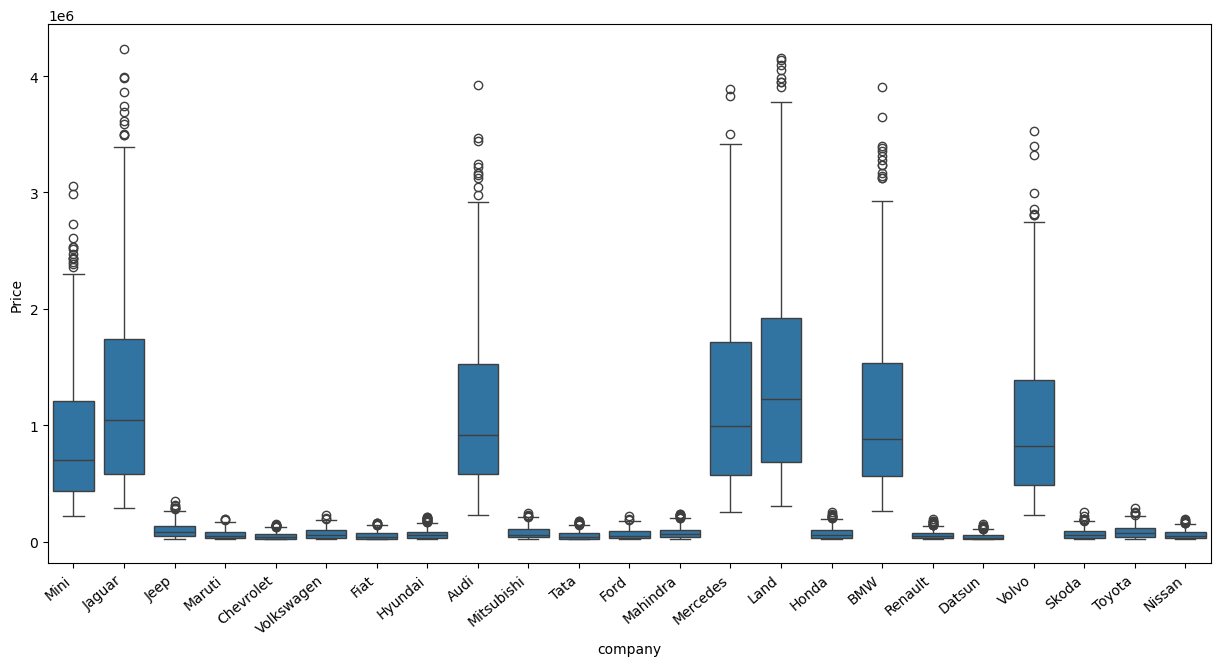

In [62]:
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company',y='Price',data=df)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

In [63]:
X=df[['name','company','year','kms_driven','fuel_type']]
y=df['Price']

In [64]:
X

,name,company,year,kms_driven,fuel_type
0,Mini Cooper S,Mini,2002,72197,Petrol
1,Jaguar XE Prestige,Jaguar,2020,110704,Petrol
2,Jeep Compass Longitude,Jeep,2019,52224,Diesel
3,Maruti Suzuki Swift,Maruti,2015,89294,Diesel
4,Chevrolet Beat LT,Chevrolet,2004,99695,Petrol
...,...,...,...,...,...
10148,Volvo XC60 D5,Volvo,2019,5834,Diesel
10149,Chevrolet Beat LT,Chevrolet,2003,167316,Petrol
10150,Honda Civic 1.8,Honda,2004,117174,Petrol
10151,Ford Figo,Ford,2021,10762,Diesel


In [65]:
y.shape

(10153,)

In [66]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [67]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [75]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

In [76]:
lr=LinearRegression()

In [77]:
pipe=make_pipeline(column_trans,lr)

In [78]:
pipe.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
y_pred=pipe.predict(X_test)

In [80]:
r2_score(y_test,y_pred)

0.7308871464065569

In [88]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i+1)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [89]:
np.argmax(scores)

np.int64(769)

In [90]:
scores[np.argmax(scores)]

0.7669221380959792

In [91]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([474164.46634887])

In [92]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

0.71361050071921

In [93]:
import pickle

In [94]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [95]:
pipe.predict(pd.DataFrame(columns=['name','company','year','kms_driven','fuel_type'],data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([459492.2663642])

In [96]:
pipe.steps[0][1].transformers[0][1].categories[0]

array(['Audi A4 35', 'Audi A6 2.0', 'Audi A8', 'Audi Q3 35', 'Audi Q7',
       'BMW 3 Series', 'BMW 5 Series', 'BMW X1 sDrive20d',
       'Chevrolet Beat LT', 'Chevrolet Sail UVA', 'Chevrolet Spark LT',
       'Chevrolet Tavera Neo', 'Datsun GO Plus', 'Datsun GO T',
       'Datsun redi-GO T', 'Fiat Linea Active', 'Fiat Punto Active',
       'Ford EcoSport Ambiente', 'Ford EcoSport Titanium',
       'Ford Endeavour 4x4', 'Ford Fiesta Classic', 'Ford Figo',
       'Ford Figo Aspire', 'Ford Freestyle Titanium', 'Honda Amaze S',
       'Honda Brio S', 'Honda City 1.5', 'Honda Civic 1.8',
       'Honda Jazz V', 'Honda WR-V i-VTEC', 'Hyundai Creta 1.6',
       'Hyundai Elite i20', 'Hyundai Eon Era', 'Hyundai Grand i10',
       'Hyundai Santro Xing', 'Hyundai Tucson 2WD', 'Hyundai Venue SX',
       'Hyundai Verna 1.6', 'Hyundai Xcent S', 'Hyundai i10 Sportz',
       'Jaguar XE Prestige', 'Jaguar XF Portfolio',
       'Jeep Compass Limited', 'Jeep Compass Longitude',
       'Land Rover Discove